I need to make a plot of the multiple different kinds of objects that are in our survey

So I need to decide which objects to put in. Chris said he wants me to pick objects that were not previously known in each category or that are likely to have been excluded for one reason or another, so I guess let's go with

- Gaia J1644-0449 DZ
- SDSS J1150+2403 DC
- SDSS J1555+1330 WD+dM
- Gaia J2053+1302 DQpec

In [1]:
from __future__ import print_function
import numpy as np
import matplotlib.pyplot as plt
import sys
import os
from astropy.io import fits
from glob import glob
from astropy.time import Time
from astropy import coordinates as coords
from astropy import units as u
from astropy import constants as const
from astropy import convolution as conv
from astropy.table import Table, Column
import scipy.interpolate as scinterp
import time
start = time.time()

import wdatmos
import spec_plot_tools as spt
import cal_params as cp

print(os.getcwd())

/Users/BenKaiser/Desktop/radial_velocity_calculations


In [2]:
import plot_spec as ps



no file_setting specificied




In [37]:
target_dir= '/Users/BenKaiser/Desktop/NSF_AAG_2019/example_data/'
J1644_file= 'ravg_fwctb.GaiaJ1644m0449_20190825_400m2.fits'
J1150_file='ravg_fwctb.SDSSJ1150p2403_400m2.fits'
J1555_file='ravg_fwctb.SDSSJ1555p1330_new_400m2.fits'
J2053_file= 'avg_fwctb.gaiaj2053p1302_400m2.fits'

In [4]:
os.chdir(target_dir)

In [38]:
J1644_spec, header, noise= spt.retrieve_spec(J1644_file)
J1150_spec, header, noise= spt.retrieve_spec(J1150_file)
J1555_spec, header, noise= spt.retrieve_spec(J1555_file)
J2053_spec, header, noise= spt.retrieve_spec(J2053_file)

In [39]:
sm_J1644_spec= ps.convolve_spectrum(J1644_spec, header, kernel_type='box', pix_width=3)
sm_J1150_spec= ps.convolve_spectrum(J1150_spec, header, kernel_type='box', pix_width=3)
sm_J1555_spec= ps.convolve_spectrum(J1555_spec, header, kernel_type='box', pix_width=3)
sm_J2053_spec= ps.convolve_spectrum(J2053_spec, header, kernel_type='box', pix_width=3)

In [40]:
#norm_range=[7490, 7510]
norm_range=[6630,6690]

In [41]:
sm_J1644_spec= ps.norm_spectrum(sm_J1644_spec, norm_range, show_norm_range=False)
sm_J1150_spec= ps.norm_spectrum(sm_J1150_spec, norm_range, show_norm_range=False)
sm_J1555_spec= ps.norm_spectrum(sm_J1555_spec, norm_range, show_norm_range=False)
sm_J2053_spec= ps.norm_spectrum(sm_J2053_spec, norm_range, show_norm_range=False)





wavelength-based norm range selected [6630, 6690]





wavelength-based norm range selected [6630, 6690]





wavelength-based norm range selected [6630, 6690]





wavelength-based norm range selected [6630, 6690]





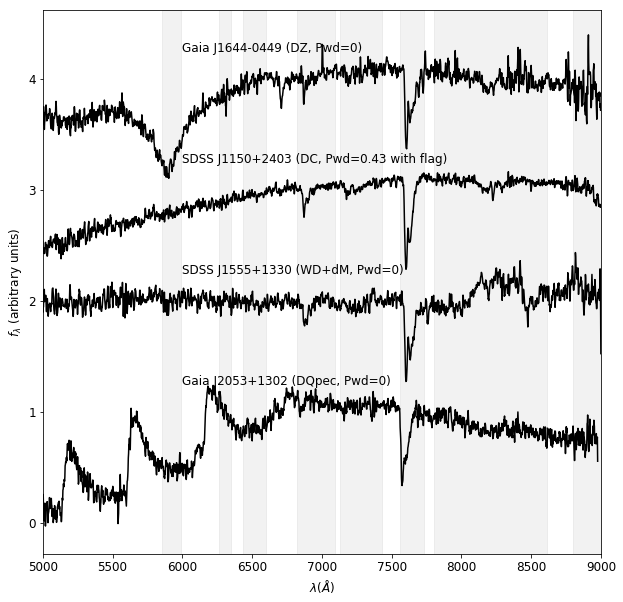

In [42]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(10,10))
label_pos=3.3
label_off=20
x_pos= 6000
y_pos= 1.25

plt.plot(sm_J2053_spec[0], sm_J2053_spec[1], color='k')
plt.plot(sm_J1555_spec[0], sm_J1555_spec[1]+1, color='k')
plt.plot(sm_J1150_spec[0], sm_J1150_spec[1]+2, color='k')
plt.plot(sm_J1644_spec[0], sm_J1644_spec[1]+3, color='k')


plt.text(x_pos, y_pos, 'Gaia J2053+1302 (DQpec, Pwd=0)', color='k')
plt.text(x_pos, y_pos+1, 'SDSS J1555+1330 (WD+dM, Pwd=0)', color='k')
plt.text(x_pos, y_pos+2, 'SDSS J1150+2403 (DC, Pwd=0.43 with flag)', color='k')
plt.text(x_pos, y_pos+3, 'Gaia J1644-0449 (DZ, Pwd=0)', color='k')

plt.ylabel(r'$f_{\lambda}$ (arbitrary units)')
plt.xlabel(r'$\lambda(\AA)$')


plt.xlim(5000,9000)
spt.show_plot(show_legend=False)

So I suspect the resizing of this won't work either since the font will remain the same overall size, which means it will overlap with the plots...

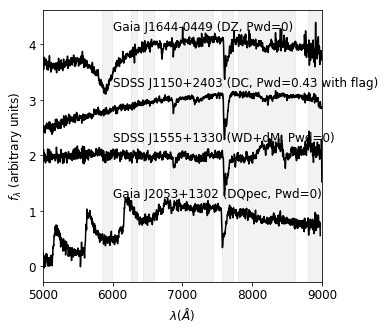

In [43]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(5,5))
label_pos=3.3
label_off=20
x_pos= 6000
y_pos= 1.25

plt.plot(sm_J2053_spec[0], sm_J2053_spec[1], color='k')
plt.plot(sm_J1555_spec[0], sm_J1555_spec[1]+1, color='k')
plt.plot(sm_J1150_spec[0], sm_J1150_spec[1]+2, color='k')
plt.plot(sm_J1644_spec[0], sm_J1644_spec[1]+3, color='k')


plt.text(x_pos, y_pos, 'Gaia J2053+1302 (DQpec, Pwd=0)', color='k')
plt.text(x_pos, y_pos+1, 'SDSS J1555+1330 (WD+dM, Pwd=0)', color='k')
plt.text(x_pos, y_pos+2, 'SDSS J1150+2403 (DC, Pwd=0.43 with flag)', color='k')
plt.text(x_pos, y_pos+3, 'Gaia J1644-0449 (DZ, Pwd=0)', color='k')

plt.ylabel(r'$f_{\lambda}$ (arbitrary units)')
plt.xlabel(r'$\lambda(\AA)$')


plt.xlim(5000,9000)
spt.show_plot(show_legend=False)

Yep, it's way too big of text...

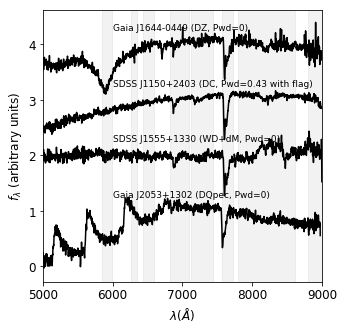

In [46]:
plt.rc('font',size=12)
fig= plt.figure(figsize=(5,5))
label_pos=3.3
label_off=20
x_pos= 6000
y_pos= 1.25

plt.plot(sm_J2053_spec[0], sm_J2053_spec[1], color='k')
plt.plot(sm_J1555_spec[0], sm_J1555_spec[1]+1, color='k')
plt.plot(sm_J1150_spec[0], sm_J1150_spec[1]+2, color='k')
plt.plot(sm_J1644_spec[0], sm_J1644_spec[1]+3, color='k')

text_fontsize= 9
plt.text(x_pos, y_pos, 'Gaia J2053+1302 (DQpec, Pwd=0)', color='k', fontsize=text_fontsize)
plt.text(x_pos, y_pos+1, 'SDSS J1555+1330 (WD+dM, Pwd=0)', color='k', fontsize=text_fontsize)
plt.text(x_pos, y_pos+2, 'SDSS J1150+2403 (DC, Pwd=0.43 with flag)', color='k',fontsize=text_fontsize)
plt.text(x_pos, y_pos+3, 'Gaia J1644-0449 (DZ, Pwd=0)', color='k',fontsize=text_fontsize)

plt.ylabel(r'$f_{\lambda}$ (arbitrary units)')
plt.xlabel(r'$\lambda(\AA)$')


plt.xlim(5000,9000)
spt.show_plot(show_legend=False)

So... I think it might actually just be easier to increase the fontsize of the axes so that when Chris shrinks it down to size again, the axes will be a good size. 

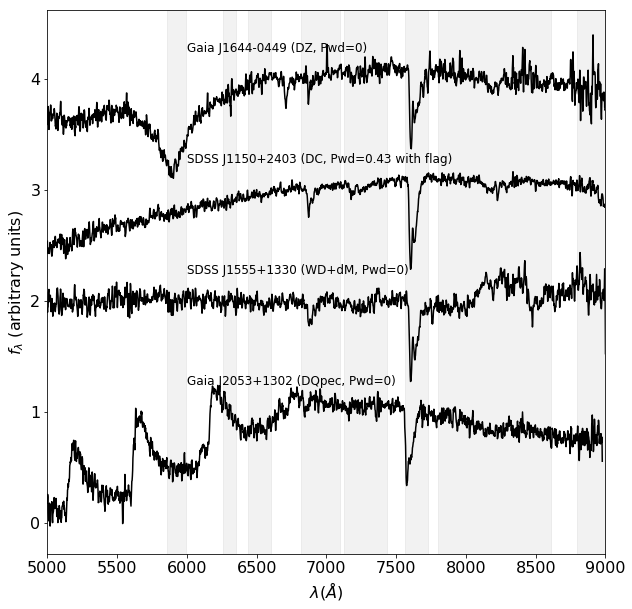

In [47]:
plt.rc('font',size=16)
fig= plt.figure(figsize=(10,10))
label_pos=3.3
label_off=20
x_pos= 6000
y_pos= 1.25

plt.plot(sm_J2053_spec[0], sm_J2053_spec[1], color='k')
plt.plot(sm_J1555_spec[0], sm_J1555_spec[1]+1, color='k')
plt.plot(sm_J1150_spec[0], sm_J1150_spec[1]+2, color='k')
plt.plot(sm_J1644_spec[0], sm_J1644_spec[1]+3, color='k')

text_fontsize= 12
plt.text(x_pos, y_pos, 'Gaia J2053+1302 (DQpec, Pwd=0)', color='k', fontsize=text_fontsize)
plt.text(x_pos, y_pos+1, 'SDSS J1555+1330 (WD+dM, Pwd=0)', color='k', fontsize=text_fontsize)
plt.text(x_pos, y_pos+2, 'SDSS J1150+2403 (DC, Pwd=0.43 with flag)', color='k',fontsize=text_fontsize)
plt.text(x_pos, y_pos+3, 'Gaia J1644-0449 (DZ, Pwd=0)', color='k',fontsize=text_fontsize)

plt.ylabel(r'$f_{\lambda}$ (arbitrary units)')
plt.xlabel(r'$\lambda(\AA)$')


plt.xlim(5000,9000)
spt.show_plot(show_legend=False)